---
## **Analisi Comparativa di tecniche di Anomaly Detection per serie temporali di sensori in serre agrifood**

Studentessa: Laura Pala

---

# 1. Introduzione

Le moderne serre sono dotate di numerosi sensori che monitorano continuamente parametri ambientali come temperatura e umidità. Questi dispositivi generano grandi quantità di dati che vengono utilizzati per controllare il microclima e supportare le decisioni agronomiche. Tuttavia, nel corso del funzionamento possono verificarsi malfunzionamenti dei sensori, problemi di alimentazione o errori di trasmissione che producono misurazioni non attendibili.

Questo progetto affronta il problema dell'identificazione delle misurazioni anomale all'interno di serie temporali provenienti da sensori ambientali.

Il problema rientra nell'ambito dell'anomaly detection su serie temporali in modalità non supervisionata, il dataset non contiene infatti etichette che distinguano preventivamente le osservazioni normali da quelle anomale, di conseguenza, gli algoritmi devono individuare i comportamenti sospetti analizzando esclusivamente la struttura dei dati.

Lo scopo non è soltanto individuare valori statisticamente estremi, ma rilevare eventi realmente significativi dal punto di vista applicativo, come il guasto di un sensore.
L'obiettivo è quindi quello di confrontare differenti tecniche di rilevamento delle anomalie, partendo da metodi statistici di base fino ad arrivare a modelli di machine learning e di analisi delle serie temporali.

Il confronto tra approcci differenti permette di evidenziare punti di forza e limiti di ciascun metodo e di comprendere come la rappresentazione dei dati influenzi la capacità di individuare diversi tipi di anomalie.

Nel contesto agricolo il controllo di temperatura e umidità è essenziale per garantire condizioni ottimali di crescita delle colture (ventilazione,irrigazione o del riscaldamento della serra).

Un sistema di rilevamento automatico delle anomalie risulta quindi utile sia per individuare tempestivamente eventuali guasti dei sensori sia per migliorare l'affidabilità complessiva del sistema di monitoraggio, contribuendo alla manutenzione predittiva e alla sicurezza della produzione.



In [82]:
# LIBRERIE NECESSARIE

import pandas as pd                            # manipolazione dati
import numpy as np
import matplotlib.pyplot as plt                # data viz
from matplotlib.lines import Line2D

# ML, serie temporali e forecasting
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


# Metriche di valutazione
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

# riproducibilità e visualizzazione
np.random.seed(42)
pd.set_option('display.max_columns', 50)

# 2. Descrizione del dataset

## Origine
Il dataset proviene da uno studio descritto dal relativo articolo scientifico (Singh et al., *Sensors*, 2022, 22, 1326 https://www.mdpi.com/1424-8220/22/4/1326) su una campagna di monitoraggio condotta in una serra di ricerca in Belgio, su una coltura di pomodori. I dati sono stati raccolti da sensori IoT basati su tecnologia LoRaWAN e sono pubblicati su Zenodo(DOI 10.5281/zenodo.5793685). È importante notare che l'articolo utilizza questo dataset per un obiettivo diverso da quello del presente lavoro: la predizione della crescita settimanale delle piante a partire dal segnale radio (RSSI) tramite una rete neurale, il task di anomaly detection qui affrontato non è sviluppato dagli autori.

Il file originale contiene 27 fogli, uno per ciascun sensore (denominati da AF16 a AF42; la sigla "AF" indica le scatole *air-flow* in cui i sensori sono alloggiati). Ogni foglio riporta le seguenti colonne:

- **Date** e **Time**: data e ora della misurazione (colonne separate)
- **Onboard Temperature**: temperatura misurata dal sensore, in °C
- **Onboard Humidity**: umidità relativa misurata dal sensore, in %
- **RSSI** e **SNR**: indicatori di qualità del segnale radio

Le letture sono trasmesse con un intervallo di campionamento di circa 5 minutie.

Il dataset non contiene una variabile target che etichetti le misure come normali o anomale: ciò è coerente con la natura non supervisionata del task. Un riferimento di verità (*ground truth*) viene ricostruito solo in fase di valutazione, a partire da un evento di guasto coerente con i problemi hardware che gli autori documentano in termini generali nell'articolo.


**Tra i 27 sensori disponibili, in questo lavoro se ne utilizzano 5**. Sono stati selezionati mediante l'esplorazione dei fogli, tenendo conto delle seguenti peculiarità:

- **AF27**: presenta un guasto hardware evidente il 14 luglio 2020, tra le 11:19 e le 12:47, con 13 letture di temperatura fisicamente impossibili (fino a −45 °C) accompagnate da un crollo simultaneo dell'umidità (~0.1–0.3%). Questo evento fornisce il riferimento di verità per la valutazione.
- **AF39**: presenta elevata variabilità, utile per lo studio delle anomalie contestuali.
- **AF34, AF36, AF26**: sensori dal comportamento apparentemente regolare, che fungono da riferimento di normalità e da contesto per l'analisi multivariata.

I sensori coprono periodi temporali parzialmente diversi: questi aspetti vengono gestiti nella sezione sottostante (3).

# 3. Lettura e preparazione dei dati


Per garantire la riproducibilità dell'analisi, il dataset dei cinque sensori selezionati è stato preparato in un notebook dedicato e successivamente salvato in formato CSV. Il file risultante contiene 149.301 osservazioni e 8 variabili, comprendenti le informazioni temporali, le misurazioni di temperatura e umidità, gli indicatori della qualità del segnale e l'identificativo del sensore.

Nessun tipo di scaling viene applicato in questa fase: la normalizzazione, dove necessaria, verrà eseguita solo per i modelli che la richiedono.

**I valori anomali non vengono rimossi: essi costituiscono l'oggetto stesso dell'analisi** e in questa sezione vengono effettuate le operazioni di preparazione del dataset necessarie per renderlo adatto a tale analisi:
- unione delle misurazioni dei diversi sensori
- selezione della finestra temporale di interesse
- ricampionamento a frequenza oraria
- gestione dei valori mancanti.

## Caricamento del dataset

In [83]:
# Caricamento del dataset ridotto a 5 sensori e check sul caricamento effettivo
datasetprogetto = 'https://drive.google.com/uc?id=19bcbieRudfETRJbgWR4owGgsSHZYgB2e'
df = pd.read_csv(datasetprogetto)

df.head()

,Date,Time,Onboard Temperature,Onboard Humidity,RSSI,SNR,sensor_id,timestamp
0,2020-04-10,13:57:09,27.598,28.099,-82,10.2,AF27,2020-04-10 13:57:09
1,2020-04-10,14:07:27,27.585,27.805,-87,13.2,AF27,2020-04-10 14:07:27
2,2020-04-10,14:12:35,27.614,27.372,-88,13.5,AF27,2020-04-10 14:12:35
3,2020-04-10,14:22:52,27.556,26.766,-85,12.5,AF27,2020-04-10 14:22:52
4,2020-04-10,14:28:01,27.572,26.740,-84,11.5,AF27,2020-04-10 14:28:01


Verifichiamo la struttura del dataset: tipi delle colonne e presenza di valori
mancanti.

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149301 entries, 0 to 149300
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 149301 non-null  object 
 1   Time                 149301 non-null  object 
 2   Onboard Temperature  149301 non-null  float64
 3   Onboard Humidity     149301 non-null  float64
 4   RSSI                 149301 non-null  int64  
 5   SNR                  149301 non-null  float64
 6   sensor_id            149301 non-null  object 
 7   timestamp            149301 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 9.1+ MB


La colonna `timestamp` è stata caricata come stringa (`object`) dunque la convertiamo in tipo `datetime`, necessario per tutte le operazioni temporali successive (filtri per data, ricampionamento). Impostiamo inoltre `timestamp` come indice del DataFrame.

In [85]:
# Conversione a datetime
df['timestamp']=pd.to_datetime(df['timestamp'])

# Verifica del nuovo tipo
print(df['timestamp'].dtype)

datetime64[ns]


## Rimozione delle colonne non necessarie

Eliminiamo le colonne che non servono all'analisi:
- `Date` e `Time`: informazioni ormai contenute in `timestamp`;
- `RSSI` e `SNR`: metriche di qualità del segnale radio, non pertinenti
  all'anomaly detection su temperatura e umidità.

Inifine rinominiamo le colonne delle misure in nomi più pratici da usare.

In [86]:
# Rimozione
df=df.drop(columns=['Date', 'Time', 'RSSI', 'SNR'])

# Rename
df=df.rename(columns={
    'Onboard Temperature':'temperature',
    'Onboard Humidity':'humidity'
})

# check
df.head()

,temperature,humidity,sensor_id,timestamp
0,27.598,28.099,AF27,2020-04-10 13:57:09
1,27.585,27.805,AF27,2020-04-10 14:07:27
2,27.614,27.372,AF27,2020-04-10 14:12:35
3,27.556,26.766,AF27,2020-04-10 14:22:52
4,27.572,26.740,AF27,2020-04-10 14:28:01


## Restrizione alla finestra temporale di interesse

Prima di procedere con l'analisi è necessario limitare il periodo osservato. I sensori sono stati accesi in una stanza il 10 aprile 2020 e installati nella serra solo il 17 aprile alle 06:38: le misurazioni precedenti a tale data corrispondono alla fase di test e configurazione dei dispositivi e non riflettono le reali condizioni ambientali della serra, vengono quindi escluse dall'analisi.

Anche la parte finale della serie viene troncata al 28 luglio 2020, data dell'ultima trasmissione del sensore AF27. Adottare una finestra temporale comune a tutti i sensori evita confronti tra serie di durata differente e garantisce la coerenza delle analisi successive.

In [87]:
# I sensori entrano in serra il 17 aprile 2020 alle 06:38
data_inst_serra='2020-04-17 06:38:00'


n_prima=len(df)
df = df[df['timestamp'] >= data_inst_serra].reset_index(drop=True)

# Fine della finestra di analisi: ultimo messaggio di AF27.
# Oltre questa data i sensori si spengono in momenti diversi

# fine_finestra è calcolata usando (.max() di AF27).
fine_finestra=df[df['sensor_id'] == 'AF27']['timestamp'].max()

n_prima=len(df)
df = df[df['timestamp'] <= fine_finestra].reset_index(drop=True)

## Passaggio a formato wide e ricampionamento orario

I cinque sensori non trasmettono le misurazioni negli stessi istanti, ma con intervalli medi di circa cinque minuti e lievi disallineamenti temporali. Per poterli confrontare nello stesso istante, il dataset viene trasformato dal formato *long* al formato *wide*, ottenendo una colonna dedicata alla temperatura e una all'umidità per ciascun sensore.

Le osservazioni vengono poi ricampionate a frequenza oraria, calcolando la media delle misurazioni disponibili in ciascuna ora. Questa scelta allinea i sensori su una griglia temporale comune, riduce il rumore ad alta frequenza delle letture e preserva il ciclo giornaliero (24 osservazioni al giorno), mantenendo una risoluzione sufficiente a individuare eventi anomali di durata limitata.

In [88]:
#Da long a wide: una colonna per ogni coppia (misura, sensore)
wide= df.pivot_table(
    index='timestamp',
    columns='sensor_id',
    values=['temperature', 'humidity']
)

# rinominiamo le colonne in temp_AF27 / hum_AF27 per comodità.
abbrev = {'temperature': 'temp', 'humidity': 'hum'}
wide.columns = [f"{abbrev[misura]}_{sensore}" for misura, sensore in wide.columns]

# campionamento a frequenza oraria con la media
orario = wide.resample('1h').mean()

print(f"dimensioni df: {orario.shape}")
orario.head()

dimensioni df: (2446, 10)


,hum_AF26,hum_AF27,hum_AF34,hum_AF36,hum_AF39,temp_AF26,temp_AF27,temp_AF34,temp_AF36,temp_AF39
timestamp,,,,,,,,,,
2020-04-17 06:00:00,83.775000,83.191000,78.688600,82.999000,76.912000,20.755333,20.495000,20.251600,20.517250,20.960500
2020-04-17 07:00:00,80.072182,77.186182,81.778100,80.433364,79.101167,23.339182,23.523364,23.737500,23.651000,23.750667
2020-04-17 08:00:00,78.827364,72.386667,75.452000,77.149182,76.755455,25.525727,26.033333,26.763583,25.374364,25.342818
2020-04-17 09:00:00,70.801000,62.768500,66.450182,67.229636,66.391300,26.161600,27.188100,28.222091,26.358182,26.290900
2020-04-17 10:00:00,68.379273,59.813100,65.607500,64.161091,63.496455,26.820545,27.990800,28.535917,27.327909,27.255000


**Il ricampionamento può produrre delle celle vuote** laddove un sensore non abbia trasmesso alcun messaggio durante la finestra oraria.
Il fenomeno va prima quantificato e poi gestito.

In [89]:
nan_count = orario.isna().sum()
nan_pct = (orario.isna().mean() * 100).round(1)
print(pd.DataFrame({'NaN': nan_count, '%': nan_pct}))

           NaN     %
hum_AF26   327  13.4
hum_AF27   235   9.6
hum_AF34   218   8.9
hum_AF36   780  31.9
hum_AF39   217   8.9
temp_AF26  327  13.4
temp_AF27  235   9.6
temp_AF34  218   8.9
temp_AF36  780  31.9
temp_AF39  217   8.9


## Interpolazione dei valori mancanti

Per preservare la continuità delle serie temporali, i valori mancanti sono stati sostituiti mediante interpolazione temporale (`method="time"`), il metodo stima ogni osservazione utilizzando i valori validi più vicini, pesati in funzione della distanza temporale.

È importante sottolineare che l'interpolazione interviene esclusivamente sui valori assenti e non modifica in alcun modo le osservazioni realmente registrate: le anomalie presenti nei dati originali vengono quindi conservate integralmente.

La maggior parte dei buchi da riempire è breve (1–3 ore), ma esistono alcuni blackout di trasmissione più lunghi. Su questi tratti l'interpolazione produce segmenti artificialmente lineari, privi di variabilità reale, nei quali nessuna anomalia è rilevabile: un limite dichiarato, ripreso nelle conclusioni.

Al termine dell'interpolazione il dataset risulta composto da **2446 osservazioni orarie e 10 variabili, senza valori mancanti**.

In [90]:
orario = orario.interpolate(method='time')

print(f"NaN rimasti: {orario.isna().sum().sum()}")
print(f"Shape finale: {orario.shape}")

NaN rimasti: 0
Shape finale: (2446, 10)


# 4. Visualizzazione ed EDA

Prima di applicare i metodi di anomaly detection è importante notare che statistiche descrittive e visualizzazioni permettono di individuare il comportamento normale dei sensori, far emergere anomalie visibili a occhio e verificare le relazioni tra le variabili.

Dal dominio (serra agricola) ci si attende una ciclicità giornaliera marcata e correlazione tra i sensori (misurano lo stesso microclima).

In [91]:
orario.describe().round(2)

,hum_AF26,hum_AF27,hum_AF34,hum_AF36,hum_AF39,temp_AF26,temp_AF27,temp_AF34,temp_AF36,temp_AF39
count,2446.00,2446.00,2446.00,2446.00,2446.00,2446.00,2446.00,2446.00,2446.00,2446.00
mean,69.01,68.72,69.10,64.27,66.75,22.44,22.82,22.90,22.68,22.81
std,14.87,14.88,14.32,13.41,14.56,4.32,4.96,4.59,4.21,4.47
min,28.81,18.99,26.19,28.80,27.00,11.51,-33.03,10.91,11.62,10.75
25%,57.76,58.74,58.66,54.00,56.00,19.03,19.09,19.19,19.39,19.17
50%,69.62,69.37,69.94,64.99,67.48,22.26,22.51,22.53,22.47,22.45
75%,81.09,80.58,80.43,75.33,78.46,25.33,26.20,26.10,25.60,25.94
max,97.22,98.17,98.97,92.14,98.26,36.10,35.98,35.75,34.99,35.60


**Osservazioni principali:**
- **`temp_AF27` min = −33 °C**: fisicamente impossibile per una serra belga a luglio.
  È proprio il guasto del 14 luglio, già visibile a livello di statistica globale
  (la media oraria attenua il valore grezzo di −45 °C senza cancellarlo).
- **`hum_AF27` min = 19 %**: contro 26-28 % degli altri sensori. Il guasto colpisce simultaneamente entrambi i canali di misura.
- **`temp_AF39` max = 35.6 °C**: il massimo tra i sensori. Coerente con condizioni estive estreme, non anomalo di per sé ma possibile caso studio per anomalie *contestuali*.
- **Quartili coerenti tra i sensori "normali"** (AF26, AF34, AF36, AF39): indicano un comportamento paragonabile, giustificando l'approccio multivariato successivo.

## Boxplot per sensore

Il boxplot riassume graficamente la distribuzione di ciascun sensore, evidenziando i valori oltre i baffi secondo la regola di Tukey (1.5 × IQR). Il risultato atteso è che il guasto di AF27 emerga chiaramente sotto il baffo inferiore, mentre le eventuali anomalie contestuali (come deviazioni dal ciclo giornaliero) resteranno invisibili: il boxplot è un metodo globale e ignora la dimensione temporale.

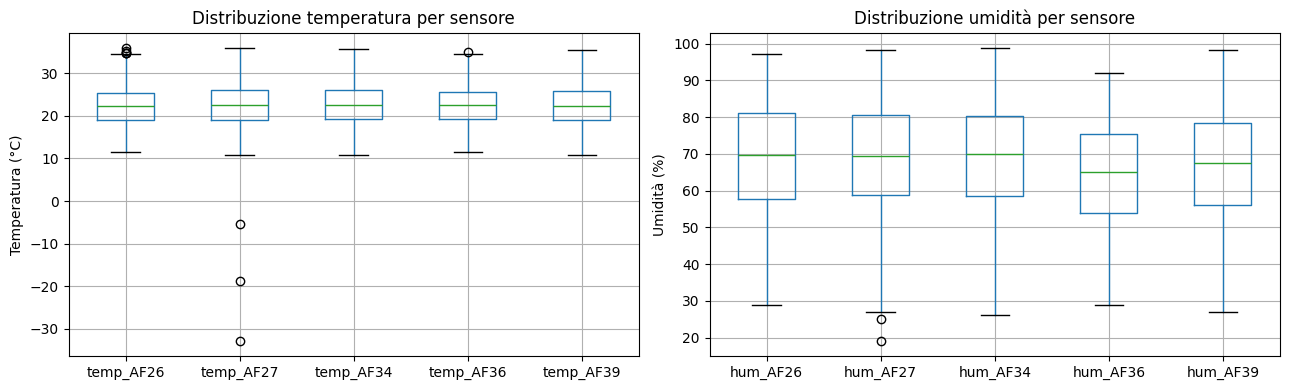

In [92]:
fig,axes=plt.subplots(1, 2, figsize=(13, 4))

# Boxplot temperatura
temp_cols = [c for c in orario.columns if c.startswith('temp_')]
orario[temp_cols].boxplot(ax=axes[0])
axes[0].set_title('Distribuzione temperatura per sensore')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].tick_params(axis='x',rotation=0)

# Boxplot umidità
hum_cols = [c for c in orario.columns if c.startswith('hum_')]
orario[hum_cols].boxplot(ax=axes[1])
axes[1].set_title('Distribuzione umidità per sensore')
axes[1].set_ylabel('Umidità (%)')
axes[1].tick_params(axis='x',rotation=0)

plt.tight_layout()
plt.show()

- **Distribuzioni delle temperature quasi identiche tra i 5 sensori**
  (box tra ~19 e ~26 °C, mediana ~22.5 °C): i sensori misurano lo stesso
  ambiente in modo coerente, prerequisito per l'analisi multivariata (Sez 6).
- **AF27 mostra tre outlier estremi a −5, −19 e −33 °C**: il guasto del
  14 luglio dopo l'aggregazione oraria. La stessa firma appare
  nell'umidità (outlier a 19 %), coerentemente con il crollo simultaneo
  dei due canali di misura durante il guasto.
- **Alcuni valori alti di temperatura (~35 °C su AF26)** sono segnalati
  come outlier dalla regola di Tukey, pur essendo temperature estive
  fisiologicamente plausibili in una serra. Questo mostra un limite
  strutturale e cio+ che rileva la componente puntuale delle anomalie ma è
cieco rispetto al **contesto temporale**: un valore normale in assoluto
può essere anomalo per l'ora in cui si presenta (anomalia contestuale).
Questa limitazione motiva l'introduzione di metodi che tengano conto del
tempo, nella Sezione 6.

## Serie temporale di AF27: il sensore del guasto del 14 luglio

Mostriamo l'intera serie oraria della temperatura di AF27 sulla finestra di analisi (17 aprile – 28 luglio 2020). Evidenziamo in rosso le ore con temperatura sotto una soglia critica (−10 °C: fisicamente impossibile in una serra belga in estate) e tracciamo una linea verticale sulla data del guasto (14 luglio). Il grafico rende visivamente evidente sia la natura puntuale del guasto (poche ore isolate su oltre 100 giorni) sia l'estraneità dei valori registrati rispetto al comportamento normale.


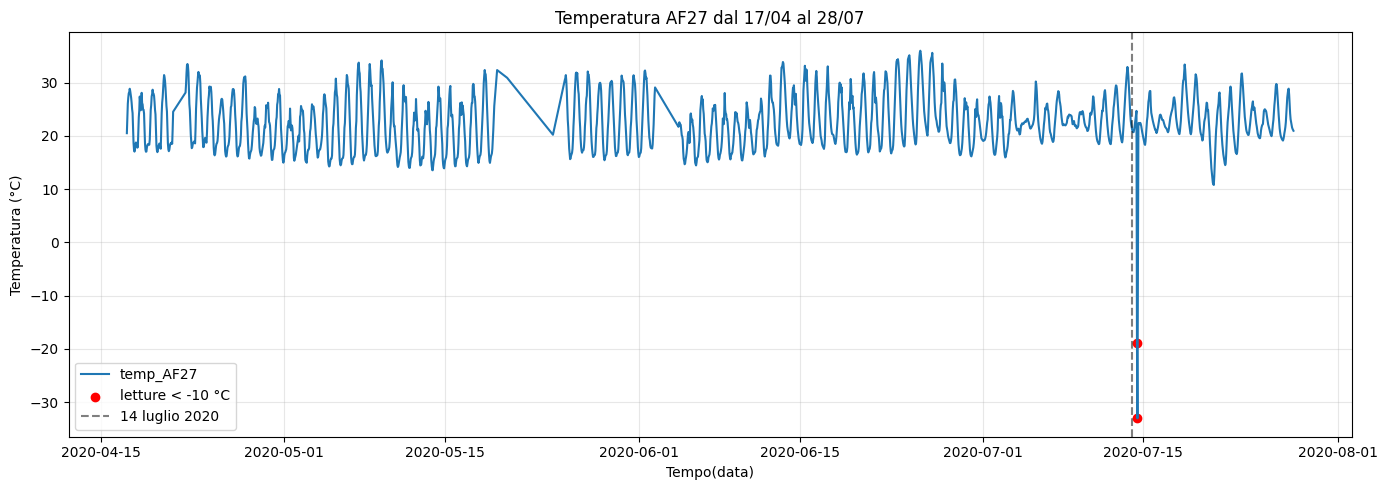

In [93]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(orario.index, orario['temp_AF27'], label='temp_AF27')

soglia = -10
anomalie = orario[orario['temp_AF27'] < soglia]
ax.scatter(anomalie.index, anomalie['temp_AF27'],
           color='red', label=f'letture < {soglia} °C')

# Linea verticale sulla data del guasto
ax.axvline(pd.Timestamp('2020-07-14'), color='black',
           linestyle='--', alpha=0.5, label='14 luglio 2020')

ax.set_title('Temperatura AF27 dal 17/04 al 28/07')
ax.set_xlabel('Tempo(data)')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Osservando il grafico notiamo:**

- che rivela un **ciclo giornaliero** molto regolare (oscillazione tra
  ~15 °C notte e ~30 °C giorno) su cui si sovrappone un lieve **trend estivo**
  crescente da giugno in poi.
- Il **problema del 14 luglio** è visibile a colpo d'occhio! Due letture orarie
  sotto la soglia dei −10 °C (rispettivamente −19 e −33 °C), circoscritte a
  poche ore e seguite da un immediato ritorno al comportamento normale.
- Le settimane successive al guasto mostrano una variabilità leggermente
  superiore alla norma. Coerente con il fatto che AF27 cessa di trasmettere
  il 28 luglio: possibili sintomi di degrado hardware progressivo.

## Decomposizione STL esplorativa su AF39

Applichiamo la decomposizione STL (Seasonal-Trend decomposition) alla
serie di AF39, un sensore con comportamento regolare ma variabile. STL separa la
serie in tre componenti: **trend** (andamento lento), **stagionalità**
(ciclo ripetitivo, in questo caso giornaliero 24 osservazioni per ciclo) e
**residuo** (ciò che resta). Utilizziamo la variante `robust`, che rende STL meno sensibile a eventuali valori estremi durante la stima.

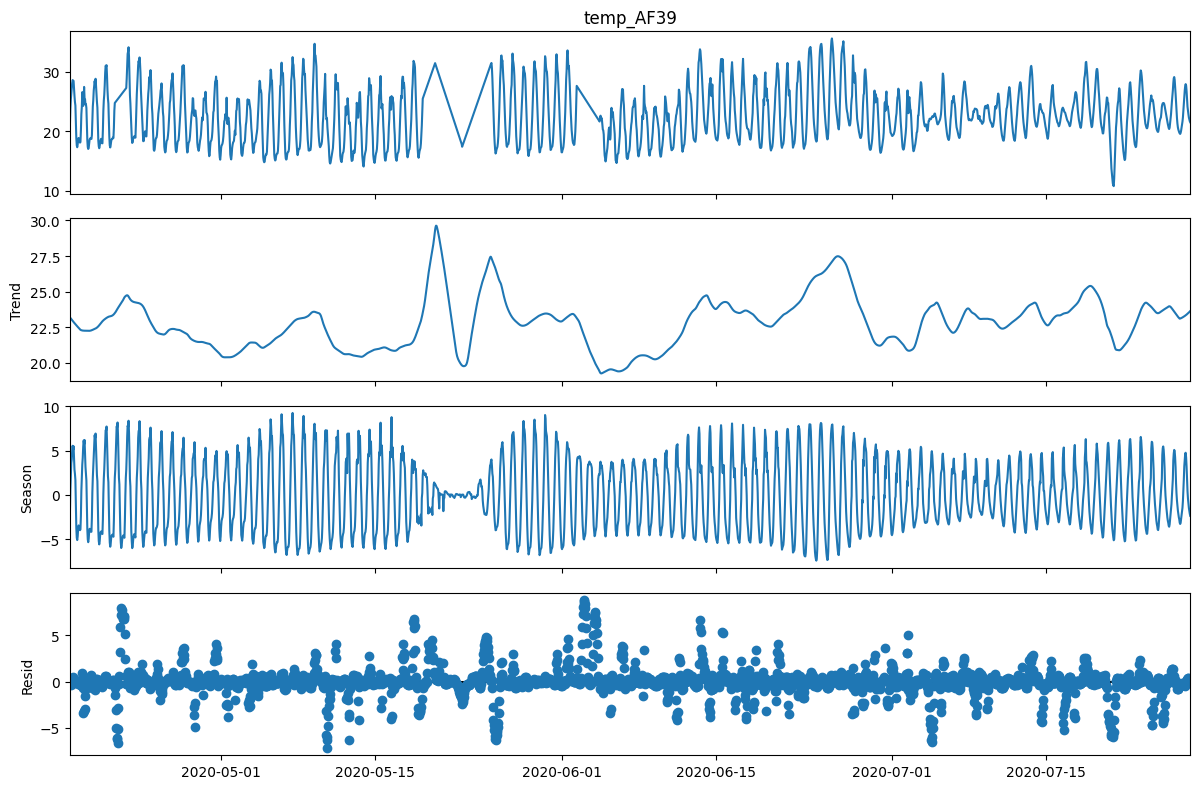

In [94]:
stl = STL(orario['temp_AF39'], period=24, robust=True)
res = stl.fit()

fig= res.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

**Cosa ci dice la decomposizione?**

- Il **trend** mostra il riscaldamento estivo ma con irregolarità marcate. La più evidente, attorno a fine maggio, corrisponde a un blackout di trasmissione diAF39: il tratto "piatto" della serie in quei giorni è un artefatto dell'interpolazione, non un fenomeno climatico.
- La **stagionalità** riflette il ciclo giornaliero (24 osservazioni per periodo), con ampiezza modulata dalla stagione: l'escursione giorno/notte estiva è più ampia di quella primaverile.
- I **residui** oscillano in una banda stretta attorno allo zero, con picchi
  occasionali fino a ±9 °C sparsi lungo tutto il periodo. Queste deviazioni
  dal comportamento atteso, non spiegate né dal trend né dal ciclo giornaliero, potrebbero essere delle anomalie contestuali che i modelli della Sezione 6 dovranno individuare.
Prima però testiamo limiti e vantaggi della baseline!

# 5. Outlier detection: metodi semplici
In questa sezione applichiamo due metodi statistici globali di outlier detection
alle serie di temperatura dei sensori, procedendo dal più semplice al più robusto:

- **5.1 Z-score classico**: media e deviazione standard
  sull'intera serie, soglia |z| > 3;
- **5.2 Modified z-score basato sul MAD** più robusto rispetto ai valori estremi: mediana e MAD, soglia |modified z| > 3.5.

L'obiettivo non è tanto trovare un metodo definitivo, quanto **evidenziare i
limiti degli approcci globali** su serie temporali. Ci aspettiamo che entrambi catturerino le anomalie estreme (puntuali) con qualità diverse, ma abbiano difficoltà nelle deviazioni locali dal comportamento atteso (contestuali).

## 5.1 Z-score classico

Lo z-score classico misura la distanza di un valore dalla media, in unità di
deviazione standard:

$$
z_i = \frac{x_i - \bar{x}}{\sigma_x}
$$

Un punto viene segnalato come anomalo se il suo z-score supera in valore
assoluto la soglia 3 (convenzione: circa il 99.7% dei dati di una distribuzione
normale cade entro ±3σ).

**Limite principale**: media e deviazione standard sono statistiche *non robuste*.
Un piccolo numero di valori estremi può spostarle in modo sensibile, riducendo la
loro capacità di rilevare gli outlier stessi (*masking effect*). Inoltre, essendo calcolate sull'intera serie, ignorano trend e stagionalità.

Applichiamo il metodo alla temperatura di ciascuno dei 5 sensori.

In [95]:
def zscore_classico(serie):
    return (serie - serie.mean()) / serie.std()

temp_cols = [c for c in orario.columns if c.startswith('temp_')]

flag_zscore = pd.DataFrame(index=orario.index)
for col in temp_cols:
    z = zscore_classico(orario[col])
    flag_zscore[col] = (z.abs() > 3).astype(int)

print("Ore segnalate come anomale dallo Z-score classico (|z| > 3):")
print(flag_zscore.sum().sort_values(ascending=False))

Ore segnalate come anomale dallo Z-score classico (|z| > 3):
temp_AF27    3
temp_AF26    1
temp_AF34    0
temp_AF36    0
temp_AF39    0
dtype: int64


Ci segnala 3 ore anomale su AF27 (coerenti con le ore del guasto già
individuate visivamente in Sez 4),un solo allarme su AF26 e nessuna anomalia sui restanti tre sensori.

Due punti da rilevare:

- Su AF27 il rilevamento del guasto avviene nonostante la sua stessa presenza
  abbia gonfiato la deviazione standard del sensore (std = 4.96 °C, la più alta
  tra i cinque). Questo è un possibile indizio di mascheramento, ma la sua
  entità andrà quantificata nel confronto con il modified z-score.
- Su AF39 nessuna anomalia viene segnalata, in contrasto con la nuvola di
  residui non nulli emersa dalla decomposizione STL (Sez 4). Questo suggerisce ancora una volta che il metodo, basato su statistiche globali, non riesca a catturare deviazioni locali dal comportamento atteso l'idea di **anomalia contestuale**.
Il confronto sistematico tra tutti i metodi (base e avanzati) sarà svolto
in Sezione 7 con un'analisi comparativa basata su: tassi di
segnalazione, consenso tra metodi, sovrapposizioni. Il ground truth verrà
utilizzato come *sanity check* per verificare che il metodo riconosca
l'evento certificato, e non come metrica principale, coerentemente con la
natura non supervisionata del task.

## 5.2 Modified z-score basato sul MAD

Il MAD (Median Absolute Deviation) è una misura di dispersione **robusta**,
basata su mediana anziché media:

$$
\text{MAD}(x) = \text{median}\left(|x_i - \text{median}(x)|\right)
$$

Il *modified z-score* usa il MAD al posto della
deviazione standard:

$$
\tilde{z}_i = \frac{0.6745 \cdot (x_i - \text{median}(x))}{\text{MAD}(x)}
$$

**Iperparametri e scelte:**

- **Costante 0.6745**: è il 75° percentile della distribuzione normale standard
  (Φ⁻¹(0.75) ≈ 0.6745). Non è un parametro tunabile, è una costante
  di normalizzazione statistica.
- **Soglia 3.5**: convenzione consolidata (Iglewicz-Hoaglin),
  leggermente più conservativa della soglia 3 dello z-score classico per
  compensare la maggiore variabilità del MAD sui piccoli campioni.
  È un iperparametro dichiarato: alzarla riduce i falsi positivi (più precision), abbassarla riduce i falsi negativi (più recall).

Il vantaggio principale rispetto allo z-score classico è la **resistenza al
masking effect**: mediana e MAD non vengono spostati dai valori estremi, quindi
gli outlier non "auto-nascondono" sé stessi inquinando le statistiche.

In [96]:
def mad(arr):
    med = np.median(arr)
    return np.median(np.abs(arr - med))

def modified_zscore(serie):
    med = np.median(serie)
    mad_val = mad(serie)
    return 0.6745 * (serie - med) / mad_val

flag_mad = pd.DataFrame(index=orario.index)
for col in temp_cols:
    mz = modified_zscore(orario[col])
    flag_mad[col] = (mz.abs() > 3.5).astype(int)

print("Ore segnalate come anomale dal Modified z-score (|mod. z| > 3.5):")
print(flag_mad.sum().sort_values(ascending=False))

Ore segnalate come anomale dal Modified z-score (|mod. z| > 3.5):
temp_AF27    3
temp_AF26    0
temp_AF34    0
temp_AF36    0
temp_AF39    0
dtype: int64


## Prima di fare le valutazioni costruiamo il ground truth di lavoro

Per confrontare quantitativamente i metodi baseline costruiamo un vettore di
etichette binarie basato sul guasto documentato di AF27 del 14 luglio 2020.

Un'ora viene etichettata come anomala (`y_true = 1`) se il **minimo** delle
letture grezze di AF27 in quell'ora scende sotto −10 °C, soglia fisicamente
impossibile in Belgio in una serra in estate. L'aggregazione tramite `min`
(invece della `mean` usata per i dati di input) è deliberata: la media
diluisce i picchi brevi del guasto un'ora con letture a −45 °C mediate a
temperature normali può risultare non anomala mentre il minimo li preserva.

Il ground truth viene qui introdotto per valutare i metodi baseline; sarà
formalizzato e riutilizzato per il confronto complessivo in Sezione 7.

In [97]:
# Serie originale (long) di AF27 con indice temporale
raw_af27 = df[df['sensor_id'] == 'AF27'].set_index('timestamp')['temperature']

# Aggregazione oraria con il MINIMO (preserva i picchi del guasto)
min_orario_af27 = raw_af27.resample('1h').min()

# Ground truth: 1 se il minimo orario è sotto la soglia fisica
soglia_gt = -10
y_true = (min_orario_af27.reindex(orario.index) < soglia_gt).astype(int)

print(f"Ore anomale nel ground truth: {y_true.sum()} su {len(y_true)}")
print(f"Percentuale: {y_true.mean()*100:.3f}%")

Ore anomale nel ground truth: 2 su 2446
Percentuale: 0.082%


Matrice di confusione **z-score**

In [98]:
y_pred_zscore = flag_zscore['temp_AF27']

print(classification_report(y_true, y_pred_zscore,
                            target_names=['normale', 'anomalia']))

pd.DataFrame(confusion_matrix(y_true, y_pred_zscore),
             index=['true_normale', 'true_anomalia'],
             columns=['pred_normale', 'pred_anomalia'])

              precision    recall  f1-score   support

     normale       1.00      1.00      1.00      2444
    anomalia       0.67      1.00      0.80         2

    accuracy                           1.00      2446
   macro avg       0.83      1.00      0.90      2446
weighted avg       1.00      1.00      1.00      2446



,pred_normale,pred_anomalia
true_normale,2443,1
true_anomalia,0,2


**Modified z-score basato sul MAD**

In [99]:
y_pred_mad = flag_mad['temp_AF27']

print(classification_report(y_true, y_pred_mad,
                            target_names=['normale', 'anomalia']))

pd.DataFrame(confusion_matrix(y_true, y_pred_mad),
             index=['true_normale', 'true_anomalia'],
             columns=['pred_normale', 'pred_anomalia'])

              precision    recall  f1-score   support

     normale       1.00      1.00      1.00      2444
    anomalia       0.67      1.00      0.80         2

    accuracy                           1.00      2446
   macro avg       0.83      1.00      0.90      2446
weighted avg       1.00      1.00      1.00      2446



,pred_normale,pred_anomalia
true_normale,2443,1
true_anomalia,0,2


Entrambi i metodi baseline rilevano il guasto documentato di AF27 (recall
pieno sul ground truth di 2 ore certificate), ma segnalano anche l'ora delle
13:00 in cui il valore interpolato risulta fuori scala mentre il dato grezzo
è mancante, un falso positivo apparente generato dall'interazione tra
interpolazione e valutazione conservativa.


Il vantaggio teorico del MAD sullo z-score classico non emerge su questo dataset: il guasto occupa 3 ore su ~2400 e non basta a spostare in modo apprezzabile media e deviazione standard.

## Analisi di sensibilità della soglia

Verifichiamo empiricamente cosa succede al variare della soglia del modified
z-score. L'obiettivo è capire se abbassando la soglia sia possibile catturare
anomalie contestuali (attese in particolare su AF39) senza generare un'esplosione
di falsi positivi. Se il risultato fosse insensibile al valore scelto, ne
concluderemmo che il limite del metodo non è la calibrazione ma la sua natura
globale.

In [100]:
soglie = [3.5, 3.0, 2.5, 2.0, 1.5]
sensibilita = pd.DataFrame(index=soglie, columns=temp_cols, dtype=int)

for col in temp_cols:
    mz = modified_zscore(orario[col])
    for t in soglie:
        sensibilita.loc[t, col] = (mz.abs() > t).sum()

sensibilita.index.name = 'soglia'
print("Numero di ore segnalate al variare della soglia:")
sensibilita

Numero di ore segnalate al variare della soglia:


,temp_AF26,temp_AF27,temp_AF34,temp_AF36,temp_AF39
soglia,,,,,
3.5,0.0,3.0,0.0,0.0,0.0
3.0,0.0,3.0,0.0,0.0,0.0
2.5,11.0,4.0,2.0,4.0,3.0
2.0,64.0,45.0,45.0,48.0,46.0
1.5,234.0,207.0,206.0,239.0,201.0



L'analisi di sensibilità della soglia (3.5 → 3.0 → 2.5 → 2.0 → 1.5) mostra che non esiste alcun valore che porti alla luce anomalie contestuali senza generare falsi positivi di massa. Il limite non è la calibrazione dell'iperparametro né la scelta della statistica.

**Il problema è  strutturale**: entrambi i metodi ignorano la struttura temporale della serie. Qualunque approccio globale può segnalare solo estremi assoluti e non le deviazioni locali dal comportamento atteso.

La Sezione 6 mantiene la stessa logica statistica (modified z-score con
soglia 3.5) ma la applica a **rappresentazioni diverse** dei dati (residui
di modelli, spazio multivariato) perchè l'idea centrale, in questo tipo di task, è che **la rappresentazione dei dati conti più della scelta dell'algoritmo**.

# 6. Implementazione dei modelli avanzati ML-based

Applichiamo cinque approcci di rilevamento che vanno oltre i metodi baseline

**Obiettivi della sezione**

- dimostrare che, cambiando la rappresentazione dei dati (residui invece di
   valori grezzi, spazio multivariato invece di serie singola), la stessa
   logica di soglia sul modified z-score produce risultati qualitativamente
   diversi;
- documentare cosa ciascun modello segnala e discuterne criticamente il
   comportamento.

I metodi impiegati per lo scopo sono:

- **6A · STL + MAD sui residui** decomposizione trend/stagionalità/residuo
- **6B · Isolation Forest multivariato** analisi congiunta dei 5 sensori
- **6C · Prophet + MAD sui residui**  modello di forecasting con ciclo Giornaliero
- **6D · ARIMA + MAD sui residui STL** autoregressione classica a confronto.
- **6.E . Finestre mobili + IF**

## 6A. STL + MAD sui residui

La decomposizione STL separa la serie in trend, stagionalità e residuo.
Se trend e stagionalità descrivono il "comportamento normale", il residuo è la
parte non spiegata: applichiamo il modified z-score (soglia 3.5, identica alla
Sezione 5) ai residui anziché ai valori grezzi.

**Iperparametri**:
- `period=24`: ciclo giornaliero su griglia oraria (24 osservazioni per ciclo),
  verificato visivamente nella STL esplorativa della Sezione 4;
- `robust=True`: variante robusta di Loess, per limitare l'influenza degli
  outlier sulla stima delle componenti;
- soglia MAD 3.5, invariata: isoliamo così l'effetto della sola rappresentazione.

In [101]:
# Decompodizione STL su AF27
ts_stl = pd.DataFrame({'y': orario['temp_AF27']})

stl = STL(ts_stl['y'], period=24, robust=True)
res = stl.fit()

ts_stl['trend_stl'] = res.trend
ts_stl['seasonal_stl'] = res.seasonal
ts_stl['resid_stl'] = res.resid

# Modified z-score sui residui
resid_med = np.median(ts_stl['resid_stl'])
resid_mad = np.median(np.abs(ts_stl['resid_stl'] - resid_med))

ts_stl['resid_stl_mz'] = 0.6745 * (ts_stl['resid_stl'] - resid_med) / resid_mad
ts_stl['pred_stl'] = (ts_stl['resid_stl_mz'].abs() > 3.5).astype(int)

print(f"Ore segnalate da STL + MAD: {ts_stl['pred_stl'].sum()} su {len(ts_stl)} "
      f"({ts_stl['pred_stl'].mean()*100:.1f}%)")

# check: le ore del guasto sono segnalate?
ore_guasto = orario.index[y_true == 1]
for t in ore_guasto:
    print(f"  {t}: segnalata={bool(ts_stl.loc[t,'pred_stl'])}, "
          f"residuo={ts_stl.loc[t,'resid_stl']:.2f} °C")

Ore segnalate da STL + MAD: 403 su 2446 (16.5%)
  2020-07-14 11:00:00: segnalata=True, residuo=-45.42 °C
  2020-07-14 12:00:00: segnalata=False, residuo=-0.70 °C


Vediamo graficamente le rilevazioni

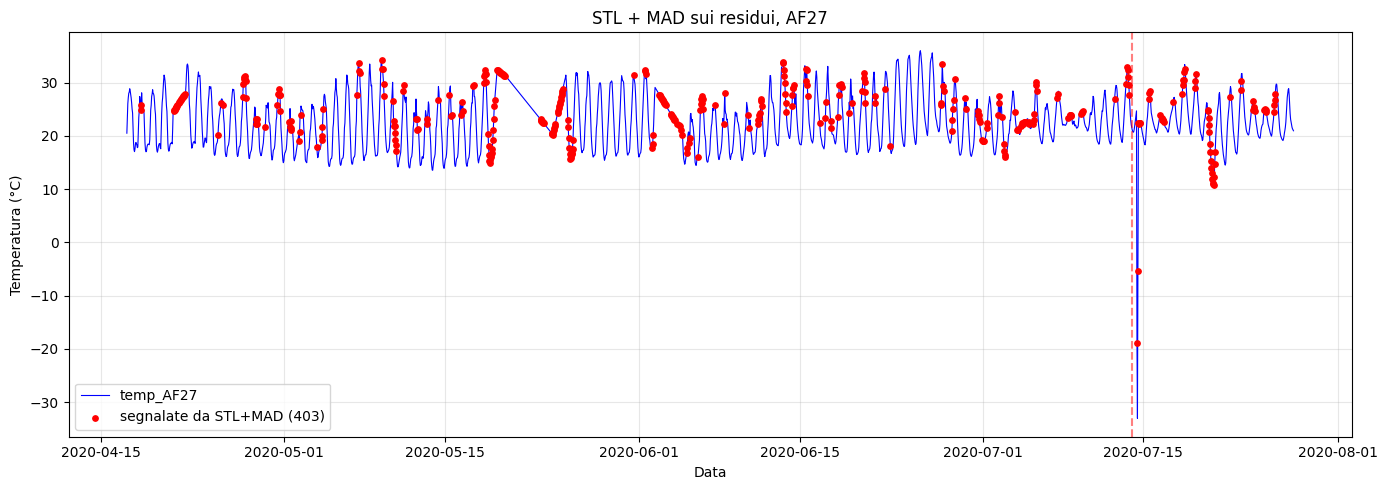

In [102]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_stl.index, ts_stl['y'], color='blue', linewidth=0.8, label='temp_AF27')
seg = ts_stl[ts_stl['pred_stl'] == 1]
ax.scatter(seg.index, seg['y'], color='red', s=15, zorder=5,
           label=f'segnalate da STL+MAD ({len(seg)})')
ax.axvline(pd.Timestamp('2020-07-14'), color='red', linestyle='--', alpha=0.5)
ax.set_title('STL + MAD sui residui, AF27')
ax.set_xlabel('Data'); ax.set_ylabel('Temperatura (°C)')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Osservazioni:**

- Il metodo segnala **403 ore (16.5%)**: un tasso di allarme molto alto, che
  include sia candidate anomalie contestuali sia semplice variabilità naturale
  che la decomposizione non spiega. Il MAD dei residui è molto piccolo (la
  metà centrale dei residui è quasi nulla), quindi la soglia 3.5 corrisponde a
  scostamenti assoluti modesti.
- **Sanity check parziale**: l'ora delle 11:00 è segnalata, ma le 12:00 che corrispondono all'ora più estrema del guasto (−33 °C), **non viene rilevata**: il suo residuo è di appena −0.7 °C. La decomposizione, pur con `robust=True`, ha assorbito parte del crollo nelle componenti di trend/stagionalità.
- Rispetto alle baseline il comportamento è opposto: molte più segnalazioni
  (sensibilità al contesto) ma minore affidabilità sull'evento estremo.

## 6B. Isolation Forest multivariato

Finora ogni sensore è stato analizzato da solo. L'Isolation Forest
osserva invece **lo stato congiunto della serra**: ogni riga è un punto in uno
spazio a 10 dimensioni (temperatura e umidità dei 5 sensori). Un punto anomalo
è "facile da isolare" con pochi tagli casuali dello spazio; l'anomaly score è
legato alla profondità media di isolamento.

**Iperparametri**:
- `contamination=0.01`: frazione attesa di anomalie (~1%), coerente con la
  rarità osservata; determina la soglia sull'anomaly score
- `n_estimators=100` (default): standard consolidato
- `random_state=42`: riproducibilità degli split casuali
- **StandardScaler prima del fit**: IF taglia lo
  spazio sui range delle feature, e temperatura (∼[−33, 36] °C) e umidità
  (∼[19, 99] %) hanno scale diverse e senza standardizzazione l'umidità
  peserebbe implicitamente di più.

In [103]:
# Standardizzazione (SOLO per IF) e fit
scaler = StandardScaler()
X_scaled = scaler.fit_transform(orario.values)

iso = IsolationForest(contamination=0.01, n_estimators=100, random_state=42)
pred_if_raw = iso.fit_predict(X_scaled)          # -1 = anomalia, 1 = normale
pred_if = pd.Series(np.where(pred_if_raw == -1, 1, 0), index=orario.index)

print(f"Ore segnalate da Isolation Forest: {pred_if.sum()} su {len(pred_if)} "
      f"({pred_if.mean()*100:.1f}%)")

# check + rank delle ore del guasto negli anomaly score
scores = -iso.score_samples(X_scaled)            # più alto = più anomalo
rank = pd.Series(scores, index=orario.index).rank(ascending=False)
for t in ore_guasto:
    print(f"  {t}: segnalata={bool(pred_if.loc[t])}, "
          f"rank anomaly score = {int(rank.loc[t])} su {len(orario)}")

# --- Quali ore segnala invece? ---
print("\nPrime 10 ore segnalate:")
print(orario.loc[pred_if == 1, 'temp_AF27'].head(10).round(1).to_string())

Ore segnalate da Isolation Forest: 25 su 2446 (1.0%)
  2020-07-14 11:00:00: segnalata=False, rank anomaly score = 324 su 2446
  2020-07-14 12:00:00: segnalata=False, rank anomaly score = 141 su 2446

Prime 10 ore segnalate:
timestamp
2020-04-20 20:00:00    18.6
2020-05-09 11:00:00    33.9
2020-05-09 12:00:00    34.2
2020-06-26 14:00:00    35.6
2020-07-07 14:00:00    28.4
2020-07-07 15:00:00    28.3
2020-07-07 16:00:00    27.7
2020-07-07 17:00:00    26.6
2020-07-12 15:00:00    29.5
2020-07-12 16:00:00    29.4


**cosa emerge?**

- IF segnala **25 ore (1.0%)**, quasi tutte pomeriggi di luglio in cui l'intera
  serra raggiunge simultaneamente valori estremi di temperatura e umidità.
- **Sanity check fallito**: le due ore del guasto non sono tra le segnalate!
  I loro anomaly score le collocano al rank 141 e 324 su 2446, alte sì, ma non
  nell'1% superiore richiesto da `contamination=0.01`.
- La spiegazione è una proprietà nota dell'algoritmo, che chiamiamo **cecità
  dimensionale**: IF isola più facilmente punti "moderatamente" anomali su
  molte dimensioni (le giornate torride: tutte e 10 le colonne estreme
  insieme) che punti estremamente anomali su poche dimensioni (il guasto
  altera 2 colonne su 10, mentre le altre 8 restano perfettamente normali).
- Il risultato non invalida il metodo: mostra che cosa IF "vede" e cioè pattern
  collettivi dell'intero sistema ma anche che cosa non vede: guasti localizzati a un singolo componente.
  
  In un sistema di monitoraggio reale sarebbe un rilevatore complementare, non sostitutivo, dei metodi univariati.

## 6C. Prophet + MAD sui residui

Prophet è un modello di forecasting che apprende trend (con changepoint) e stagionalità. A differenza di STL, che descrive la serie, Prophet genera previsioni: il residuo `y − yhat` misura quanto ogni ora si
discosta dal comportamento previsto.

Applichiamo il modified z-score ai residui.

**Iperparametri**:
- `daily_seasonality=False` + `add_seasonality(name='daily', period=1,
  fourier_order=5)`: disattiviamo la stagionalità automatica per controllare
  esplicitamente l'ordine di Fourier.
  Nota sulle unità: in Prophet`period` è espresso **in giorni** → `period=1` è il ciclo giornaliero(l'equivalente del `period=24` di STL, che conta osservazioni)
- `fourier_order=5`: compromesso tra flessibilità e rischio di inseguire le
  anomalie (un ordine alto le assorbirebbe nella stagionalità,
  auto-mascherandole, lo stesso rischio visto per STL)
- `weekly_seasonality=False`, `yearly_seasonality=False`: in serra non esiste
  un ciclo settimanale fisico, e 3 mesi di dati non consentono di stimare il
  ciclo annuale.

In [104]:
# Preparazione dati nel formato richiesto da Prophet (ds, y)
ts_prophet = pd.DataFrame({'ds': orario.index, 'y': orario['temp_AF27'].values})

# Configurazione e addestramento
m=Prophet(daily_seasonality=False,
            weekly_seasonality=False,
            yearly_seasonality=False)
m.add_seasonality(name='daily', period=1, fourier_order=5)
m.fit(ts_prophet)

# Previsione sugli stessi timestamp e residui
forecast=m.predict(ts_prophet[['ds']])
ts_prophet['yhat'] = forecast['yhat'].values
ts_prophet['resid_prophet'] = ts_prophet['y'] - ts_prophet['yhat']

# Modified z-score sui residui
med_p=np.median(ts_prophet['resid_prophet'])
mad_p=np.median(np.abs(ts_prophet['resid_prophet'] - med_p))
ts_prophet['mz_prophet'] = 0.6745 * (ts_prophet['resid_prophet'] - med_p) / mad_p
ts_prophet['pred_prophet'] = (ts_prophet['mz_prophet'].abs() > 3.5).astype(int)
pred_prophet=pd.Series(ts_prophet['pred_prophet'].values, index=orario.index)

print(f"Ore segnalate da Prophet + MAD: {pred_prophet.sum()} su {len(pred_prophet)} "
      f"({pred_prophet.mean()*100:.1f}%)")
for t in ore_guasto:
    print(f"  {t}: segnalata={bool(pred_prophet.loc[t])}")

Ore segnalate da Prophet + MAD: 20 su 2446 (0.8%)
  2020-07-14 11:00:00: segnalata=True
  2020-07-14 12:00:00: segnalata=True


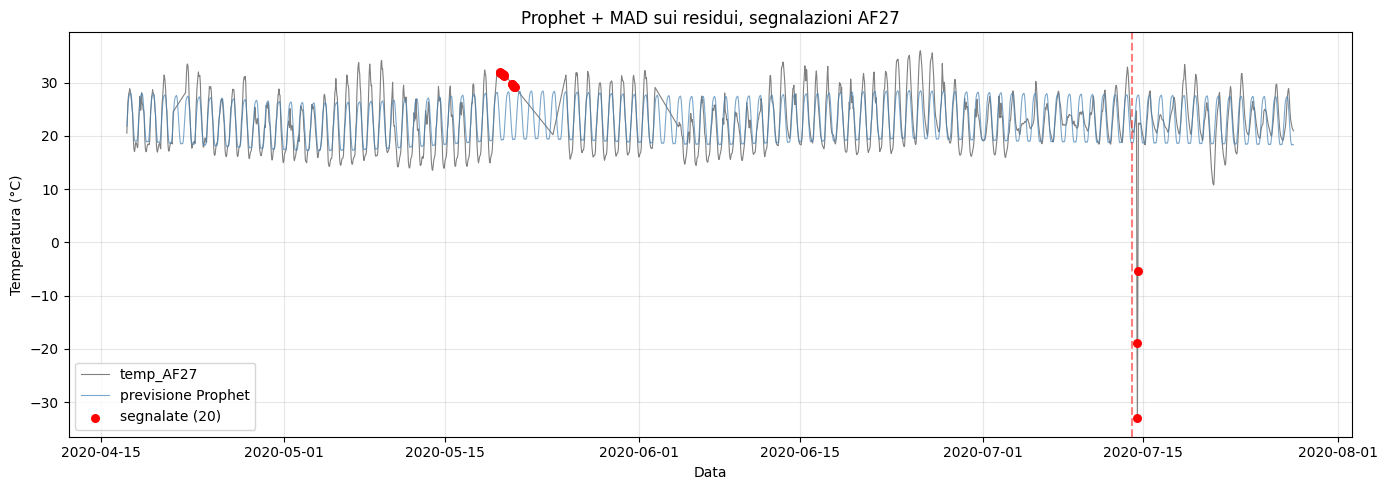

In [105]:
fig,ax=plt.subplots(figsize=(14, 5))
ax.plot(orario.index, orario['temp_AF27'], color='gray', linewidth=0.8, label='temp_AF27')
ax.plot(orario.index, ts_prophet['yhat'].values, color='steelblue',
        linewidth=0.8, alpha=0.7, label='previsione Prophet')
seg=orario.loc[pred_prophet == 1, 'temp_AF27']
ax.scatter(seg.index, seg.values, color='red', s=30, zorder=5,
           label=f'segnalate ({len(seg)})')
ax.axvline(pd.Timestamp('2020-07-14'), color='red', linestyle='--', alpha=0.5)
ax.set_title('Prophet + MAD sui residui, segnalazioni AF27')
ax.set_xlabel('Data'); ax.set_ylabel('Temperatura (°C)')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Osservazioni:**

- Prophet + MAD segnala **20 ore (0.8%)**: un tasso di allarme parsimonioso e
  gestibile in un contesto operativo reale (meno di un allarme ogni 5 giorni).
- **Sanity check pieno**: entrambe le ore certificate del guasto sono rilevate.
  A differenza di STL, la stagionalità di Prophet è vincolata a una forma
  regolare (5 armoniche di Fourier) uguale per tutto il periodo: il modello non
  può "piegarsi" localmente per assorbire il crollo del 14 luglio, e il guasto
  resta interamente nei residui.
- È il metodo con il miglior equilibrio tra sensibilità (rileva il guasto) e
  parsimonia (pochi allarmi). Le restanti segnalazioni si concentrano in ore
  di scostamento marcato dal ciclo previsto, (candidate anomalie contestuali).

## 6D. ARIMA + MAD sui residui STL

Dopo la rimozione di trend e stagionalità (STL), i residui non sono
necessariamente indipendenti nel tempo: l'inerzia termica della serra induce
autocorrelazione di breve termine. ARIMA modella questa dipendenza; i suoi
residui rappresentano ciò che *nemmeno la storia recente* riesce a spiegare.

**Iperparametri e order = (2, 0, 2)**:
- `d=0`: i residui STL sono già detrendizzati e destagionalizzati, quindi
  stazionari, nessuna differenziazione è necessaria. (Applicare ARIMA
  direttamente alla serie grezza richiederebbe SARIMA con s=24)
- `p=2, q=2`: ordini bassi per la dipendenza di breve termine mentre ordini alti
  rischierebbero overfitting.

**Ruolo nel confronto**: ARIMA modella la *dipendenza dal passato recente*,
Prophet la *struttura di calendario* quindi sono due assunzioni diverse sulla serie.

In [106]:
# sui residui della decomposizione STL (già calcolati in 6A)
arima=ARIMA(ts_stl['resid_stl'].values, order=(2, 0, 2)).fit()
resid_arima = pd.Series(arima.resid, index=orario.index)

# Modified z-score sui residui di ARIMA
med_a= np.median(resid_arima)
mad_a= np.median(np.abs(resid_arima - med_a))
mz_arima= 0.6745 * (resid_arima - med_a) / mad_a
pred_arima= (mz_arima.abs() > 3.5).astype(int)

print(f"Ore segnalate da ARIMA + MAD: {pred_arima.sum()} su {len(pred_arima)} "
      f"({pred_arima.mean()*100:.1f}%)")
for t in ore_guasto:
    print(f"  {t}: segnalata={bool(pred_arima.loc[t])}")

Ore segnalate da ARIMA + MAD: 316 su 2446 (12.9%)
  2020-07-14 11:00:00: segnalata=True
  2020-07-14 12:00:00: segnalata=True


**Deduzioni:**

- ARIMA + MAD segnala **316 ore (12.9%)**: tasso alto, simile a STL era un risultato atteso dato che lavora sui residui di quest'ultima (sovrapposizione misurata in Sezione 7).
- **Sanity check pieno**, con un dettaglio: ARIMA recupera l'ora delle
  12:00 che STL da sola aveva perso per auto-mascheramento. Il crollo, pur
  assorbito in parte dalla decomposizione, produce nei residui STL una
  transizione brusca che l'autoregressione non riesce a prevedere quindi il residuo ARIMA torna grande. La catena STL-ARIMA si comporta da correttore parziale dell'auto-mascheramento.
- Resta però un metodo che tende al "rumoroso": la maggior parte delle segnalazioni riflette la variabilità naturale non spiegata, più che eventi identificwabili.

## 6E. Outlier collettivi con finestre mobili + Isolation Forest

I metodi delle sezioni precedenti operano a livello di singola osservazione (baseline, STL, Prophet, ARIMA) o di stato istantaneo della serra (IF su singola riga). Nessuno di essi rileva pattern anomali che si estendono su più ore consecutive (**outlier collettivi**): una finestra di misurazioni che, presa nel suo insieme, si comporta in modo diverso dal resto.

L'approccio consiste nel trasformare la serie di AF27 in punti di uno spazio di feature: la temperatura viene divisa in finestre mobili di 24 ore (un giorno), e per ciascuna finestra si calcolano quattro statistiche aggregate:
`mean`, `std`, `range`, `slope`. Ogni finestra diventa così un punto in uno spazio quadridimensionale, su cui applichiamo Isolation Forest per individuare i giorni "collettivamente anomali".

**Iperparametri**:
- Ampiezza finestra: `window=24` (un giorno intero, coerente con `period=24` della STL)
- Passo: `step=1` (finestre sovrapposte, per non perdere risoluzione)
- Feature per finestra: `mean` (livello), `std` (variabilità), `range` (escursione), `slope` (tendenza)
- Isolation Forest: `contamination=0.02`, `random_state=42`

In [107]:
#costruzione delle finestre

window=24
rows=[]

for start in range(0, len(orario['temp_AF27']) - window + 1):
    end = start + window
    w = orario['temp_AF27'].iloc[start:end].to_numpy()
    x = np.arange(window)
    slope = np.polyfit(x, w, 1)[0]

    rows.append({
        "start": start,
        "end": end,
        "timestamp": orario.index[end - 1],
        "mean": w.mean(),
        "std": w.std(),
        "range": w.max() - w.min(),
        "slope": slope,
    })

win_df=pd.DataFrame(rows)
win_df.head()

,start,end,timestamp,mean,std,range,slope
0,0,24,2020-04-18 05:00:00,22.620548,4.350415,11.804417,-0.477180
1,1,25,2020-04-18 06:00:00,22.618037,4.351658,11.804417,-0.522142
2,2,26,2020-04-18 07:00:00,22.615699,4.351186,11.804417,-0.503809
3,3,27,2020-04-18 08:00:00,22.561609,4.316294,11.804417,-0.445466
4,4,28,2020-04-18 09:00:00,22.569129,4.324497,11.804417,-0.347109


In [108]:
#IF sulle feature
X_win=win_df[["mean", "std", "range", "slope"]]
X_win_s=StandardScaler().fit_transform(X_win)

iso_win = IsolationForest(contamination=0.02, random_state=42)
pred_win_raw = iso_win.fit_predict(X_win_s)
win_df["pred_collective_window"] = np.where(pred_win_raw == -1, 1, 0)

print(f"Finestre segnalate: {win_df['pred_collective_window'].sum()} su {len(win_df)}")

Finestre segnalate: 49 su 2423


In [109]:
# Proiezione delle finestre segnalate sulla griglia oraria
pred_finestre = pd.Series(0, index=orario.index)
for _, row in win_df[win_df["pred_collective_window"] == 1].iterrows():
    t_start = orario.index[row["start"]]
    t_end = orario.index[row["end"] - 1]
    mask = (orario.index >= t_start) & (orario.index <= t_end)
    pred_finestre.loc[mask] = 1

print(f"Ore complessivamente segnalate: {pred_finestre.sum()} su {len(pred_finestre)}")
for t in ore_guasto:
    print(f"  {t}: segnalata={bool(pred_finestre.loc[t])}")


Ore complessivamente segnalate: 118 su 2446
  2020-07-14 11:00:00: segnalata=True
  2020-07-14 12:00:00: segnalata=True


Vediamo graficamente cosa riesce a fare l'algoritmo

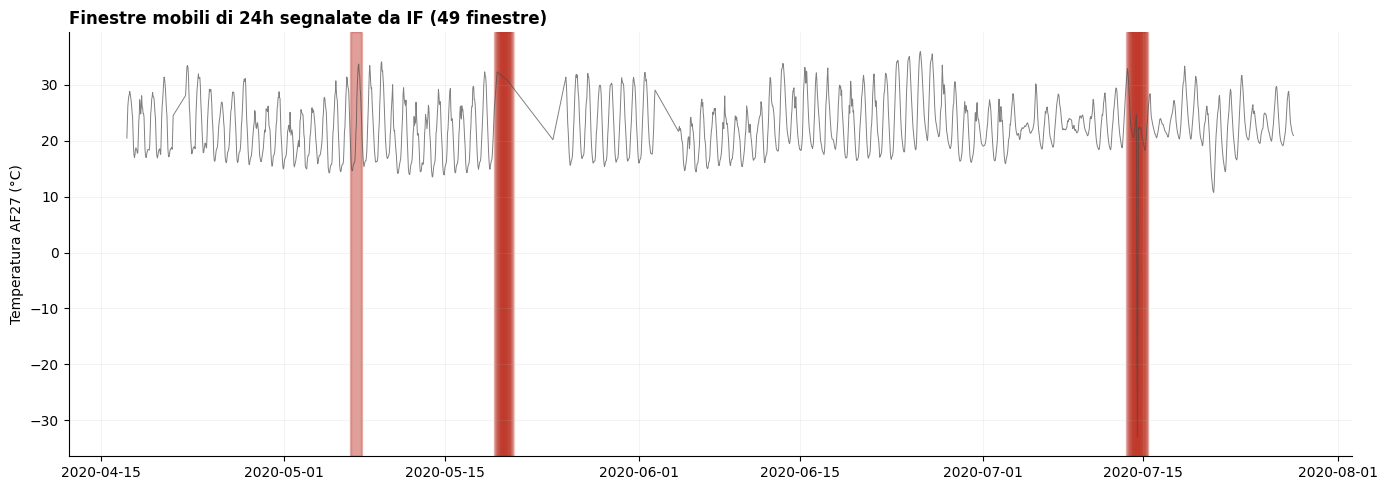

In [110]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(orario.index, orario['temp_AF27'],
        color='#4a4a4a', linewidth=0.7, alpha=0.7, label='temp_AF27')

for _, row in win_df[win_df["pred_collective_window"] == 1].iterrows():
    t_start = orario.index[row["start"]]
    t_end = orario.index[row["end"] - 1]
    ax.axvspan(t_start, t_end, color='#c0392b', alpha=0.15, zorder=1)

ax.axvline(pd.Timestamp('2020-07-14'),
           color='#c0392b', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title(f'Finestre mobili di 24h segnalate da IF ({win_df["pred_collective_window"].sum()} finestre)',
             loc='left', fontsize=12, fontweight='bold')
ax.set_ylabel('Temperatura AF27 (°C)')
ax.grid(alpha=0.2, linewidth=0.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

Il metodo segnala 49 finestre di 24 ore (~2% del totale), che proiettate sulla griglia oraria coprono 118 ore. L'ispezione delle statistiche rivela che IF individua **due tipi opposti di finestre anomale**:

- **Finestre con std e range molto elevati** (`std` fino a 15.6 °C, `range` fino a 66 °C): sono le finestre che contengono il crollo del 14 luglio. Il metodo passa il sanity check pieno, segnalando sia le 11:00 che le 12:00 certificate dal ground truth.
- **Finestre con std e range prossimi a zero** (`std` fino a 0.46 °C, `range` fino a 1.56 °C): sono i tratti in cui l'interpolazione temporale ha riempito blackout di trasmissione con segmenti quasi lineari, cancellando il ciclo giornaliero. Il metodo rileva questi periodi come collettivamente anomali perché privi di variabilità realistica.

Questa seconda categoria è di particolare interesse: le finestre mobili rendono **quantitativamente visibile** un limite del preprocessing: nei blackout lunghi l'interpolazione produce dati artificiali e nessuno dei metodi puntuali o contestuali riesce a rilevarli.

Il cambio di rappresentazione da singola osservazione a finestra aggregata è ciò che permette di catturarli!

## Riepilogo della sezione

#####
| Metodo | Ore segnalate | % | Riconosce il guasto? |
|---|---|---|---|
| STL + MAD | 403 | 16.5% | parziale (manca le 12:00) |
| ARIMA + MAD | 316 | 12.9% | sì, entrambe le ore |
| Finestre mobili + IF | 118 | 4.8% | sì, entrambe le ore |
| Isolation Forest | 25 | 1.0% | no |
| Prophet + MAD | 20 | 0.8% | sì, entrambe le ore |



Cinque rappresentazioni diverse, stessa soglia statistica, cinque comportamenti diversi: STL è molto sensibile, Prophet risulta avere estrema "cautela" e IF non vede il guasto (limite superato dalla sua stessa variante a finestre mobili, che vede lo stesso evento da una rappresentazione diversa).

##### Ci dedichiamo adesso ad un **confronto più sistematico (consenso, sovrapposizioni, tassi di allarme)**.

# 7. Valutazione e confronto dei risultati

Confrontiamo sistematicamente i sette metodi applicati (due baseline della
Sezione 5 e cinque modelli avanzati della Sezione 6) attraverso tre analisi
complementari:

1. **Sanity check sul guasto documentato** ciascun metodo riconosce l'evento
   certificato del 14 luglio? È l'unica verifica quantitativa possibile su
   ground truth, e serve come test di capacità di rilevamento minima.
2. **Tassi di allarme e concordanza** quante ore segnala ciascun metodo, e
   in che misura le sue segnalazioni si sovrappongono a quelle degli altri.
3. **Consenso tra metodi** le ore segnalate da un numero crescente di metodi
   indipendenti sono candidate anomalie con progressiva evidenza, anche in
   assenza di etichette. È il principio del *majority voting* dell'ensemble
   learning applicato all'anomaly detection.

## Raccolta delle predizioni

Raccogliamo i vettori binari di tutti i metodi in un'unica tabella allineata
sull'indice temporale della griglia oraria. Da questa struttura derivano tutte
le analisi successive.

In [111]:
predizioni = pd.DataFrame({
    'Z-score classico':      flag_zscore['temp_AF27'],
    'Modified z-score':      flag_mad['temp_AF27'],
    'STL + MAD':             ts_stl['pred_stl'],
    'Isolation Forest':      pred_if,
    'Prophet + MAD':         pred_prophet,
    'ARIMA + MAD':           pred_arima,
    'Finestre mobili + IF':  pred_finestre,
}, index=orario.index)

print(f"Shape: {predizioni.shape}")
print("\nTotale ore segnalate per metodo:")
print(predizioni.sum().sort_values(ascending=False))

Shape: (2446, 7)

Totale ore segnalate per metodo:
STL + MAD               403
ARIMA + MAD             316
Finestre mobili + IF    118
Isolation Forest         25
Prophet + MAD            20
Modified z-score          3
Z-score classico          3
dtype: int64


## Sanity check: i metodi riconoscono il guasto documentato?

Verifichiamo se ciascun metodo segnala le due ore certificate dal ground truth
(11:00 e 12:00 del 14 luglio 2020, in cui il valore grezzo di AF27 è
fisicamente impossibile), è l'unica verifica quantitativa possibile.

L'ora delle 13:00, segnalata da diversi metodi ma non presente
nel ground truth conservativo (grezzo mancante, interpolato −5.35 °C), viene
tracciata come informazione aggiuntiva.

In [112]:
ore_guasto= orario.index[y_true == 1]
ora_dubbia= pd.Timestamp('2020-07-14 13:00:00')

# per ciascun metodoci chiediamo: prende entrambe le ore del ground truth?
sanity = pd.DataFrame(index=predizioni.columns)
for t in ore_guasto:
    sanity[f'ora {t.strftime("%H:%M")}'] = predizioni.loc[t].astype(bool)
sanity['tutte del GT?'] = predizioni.loc[ore_guasto].all().values.astype(bool)
sanity[f'ora 13:00 (contestuale)'] = predizioni.loc[ora_dubbia].astype(bool)

sanity

,ora 11:00,ora 12:00,tutte del GT?,ora 13:00 (contestuale)
Z-score classico,True,True,True,True
Modified z-score,True,True,True,True
STL + MAD,True,False,False,True
Isolation Forest,False,False,False,False
Prophet + MAD,True,True,True,True
ARIMA + MAD,True,True,True,True
Finestre mobili + IF,True,True,True,True


**Conclusioni sul sanity check:**

- **Cinque metodi su sette** rilevano entrambe le ore certificate del guasto:
  Z-score classico, modified z-score, Prophet + MAD, ARIMA + MAD e Finestre
  mobili + IF.
- **STL + MAD manca l'ora delle 12:00** (l'ora più estrema, con temperatura
  interpolata a −33 °C): l'auto-mascheramento discusso nella Sezione 6A.
  ARIMA, applicato sui residui STL, recupera invece questa ora! La transizione
  brusca nei residui STL è imprevedibile per l'autoregressione, quindi il
  residuo ARIMA torna grande. La composizione STL → ARIMA agisce da correttore
  parziale dell'auto-mascheramento.
- **Isolation Forest non rileva nessuna delle due ore**, cecità dimensionale
  discussa in 6B. IF vede lo *stato congiunto* della serra e privilegia i
  pomeriggi torridi (tutte e 10 le colonne estreme insieme) rispetto a un
  guasto localizzato su 2 colonne su 10. È significativo che la variante a
  finestre mobili di IF (6E), applicata a sole quattro feature aggregate di
  un'unica serie, non soffra dello stesso limite: **la cecità non è
  dell'algoritmo ma della rappresentazione** a 10 dimensioni su cui viene
  applicato.
- **Le 13:00 del 14 luglio, esclusa dal ground truth conservativo per
  mancanza di dato grezzo, viene segnalata da sei metodi su sette.** Questo
  primo segnale di concordanza mostra il valore dell'approccio comparativo:
  informazione che le etichette non contenevano emerge dall'accordo tra
  metodi indipendenti (approfondito nell'analisi del consenso).

## Tassi di allarme

Ciascun metodo produce un numero molto diverso di segnalazioni: dalla
"parsimonia" estrema delle baseline (3 ore in oltre tre mesi) alla sensibilità
elevata di STL e ARIMA (oltre il 12% delle ore). Il tasso di allarme è un
indicatore pratico della "sensibilità" del metodo, e va sempre letto insieme
al sanity check: un metodo molto silenzioso è utile solo se coglie gli eventi
noti; un metodo molto rumoroso rischia di sommergere l'operatore e i sistemi di falsi positivi.

In [113]:
n_totale = len(predizioni)
giorni_totali = (predizioni.index[-1] - predizioni.index[0]).total_seconds() / 86400

confronto = pd.DataFrame({
    'ore segnalate': predizioni.sum(),
    '% ore': (predizioni.sum() / n_totale * 100).round(2),
    'allarmi/giorno': (predizioni.sum() / giorni_totali).round(2),
    'sanity check': sanity['tutte del GT?'].values,
}).sort_values('ore segnalate', ascending=False)

confronto

,ore segnalate,% ore,allarmi/giorno,sanity check
STL + MAD,403,16.48,3.96,False
ARIMA + MAD,316,12.92,3.10,True
Finestre mobili + IF,118,4.82,1.16,True
Isolation Forest,25,1.02,0.25,False
Prophet + MAD,20,0.82,0.20,True
Modified z-score,3,0.12,0.03,True
Z-score classico,3,0.12,0.03,True


## Consenso tra metodi

Con sette metodi indipendenti che analizzano la stessa serie da angolazioni
diverse (statistica globale, decomposizione, forecasting, autoregressione,
isolamento multivariato, isolamento su finestre aggregate), la concordanza
tra metodi è di per sé un indicatore di anomalia, indipendente dal ground
truth.

Il principio è quello del **majority voting** dell'ensemble learning: un metodo singolo può segnalare un falso positivo, ma se più metodi con logiche diverse concordano su una stessa ora, quella concordanza è per costruzione più affidabile del giudizio del singolo metodo.

Nel nostro contesto, dove il ground truth copre solo un evento puntuale e
molte segnalazioni dei metodi contestuali potrebbero essere anomalie reali
non etichettate, il consenso diventa lo strumento naturale per stimare la
confidenza di ogni segnalazione senza bisogno di label complete.

In [114]:
# Numero di metodi che concordano per ogni ora
consenso = predizioni.sum(axis=1)
predizioni['consenso'] = consenso

# Distribuzione: quante ore sono segnalate da almeno k metodi?
distrib_consenso = pd.DataFrame({
    'almeno k metodi': range(1, 8),
    'ore': [(consenso >= k).sum() for k in range(1, 8)],
    '% ore': [round((consenso >= k).mean() * 100, 2) for k in range(1, 8)],
})
distrib_consenso

,almeno k metodi,ore,% ore
0,1,554,22.65
1,2,289,11.82
2,3,29,1.19
3,4,11,0.45
4,5,3,0.12
5,6,2,0.08
6,7,0,0.00


In [115]:
# Le ore maggior consenso: quali sono e chi le ha segnalate
top_consenso = predizioni[predizioni['consenso'] >= 4].sort_values('consenso', ascending=False)
top_consenso

,Z-score classico,Modified z-score,STL + MAD,Isolation Forest,Prophet + MAD,ARIMA + MAD,Finestre mobili + IF,consenso
timestamp,,,,,,,,
2020-07-14 13:00:00,1,1,1,0,1,1,1,6
2020-07-14 11:00:00,1,1,1,0,1,1,1,6
2020-07-14 12:00:00,1,1,0,0,1,1,1,5
2020-05-19 22:00:00,0,0,1,0,1,1,1,4
2020-05-19 21:00:00,0,0,1,0,1,1,1,4
2020-05-19 20:00:00,0,0,1,0,1,1,1,4
2020-05-19 23:00:00,0,0,1,0,1,1,1,4
2020-07-13 15:00:00,0,0,1,1,0,1,1,4
2020-07-13 12:00:00,0,0,1,1,0,1,1,4


**Osservazioni sul consenso:**

- Il consenso tra metodi scende bruscamente al crescere del numero di metodi concordi: 554 ore (~23%) sono segnalate da almeno un metodo, ma solo **3 ore** raggiungono almeno 5 voti su 7, e **2 ore** raggiungono 6 voti su 7.
- **Le tre ore ad alto consenso (≥ 5 metodi concordi) sono tutte del 14 luglio 2020** , 11:00, 12:00 e 13:00, cioè l'intera durata del guasto documentato. Il meccanismo di consenso isola l'evento senza aver mai usato il ground truth in fase di analisi.
- Le due ore che raggiungono il consenso massimo (6 voti su 7) sono le **11:00 e le 13:00**. È un risultato notevole: le 11:00 sono nel ground truth conservativo, ma **le 13:00 no**, erano state escluse perché il dato grezzo di quell'ora era mancante e il valore interpolato non superava la soglia fisica del ground truth tuttavia sei metodi indipendenti, senza vedere le etichette, concordano che quest'ora è anomala.
- Le 12:00, che sarebbero l'ora più estrema del guasto (−33 °C interpolato) e formalmente nel ground truth, ottengono "solo" 5 voti su 7 perché Isolation Forest la manca e STL + MAD la perde.Si tratta del caso più chiaro in cui il consenso compensa i fallimenti dei singoli metodi.
- Le otto ore a consenso intermedio (4 voti su 7) si concentrano in due episodi:la notte tra il 19 e il 20 maggio e i pomeriggi del 13 luglio  segnalati dai metodi contestuali ma non dalle baseline: candidate anomalie contestuali, prive di riscontro nel ground truth ma coerenti con il tipo di deviazione che questi metodi sono progettati per rilevare.
- **L'analisi comparativa non si limita a isolare il giorno del guasto: recupera un'ora che il ground truth non poteva certificare.È la dimostrazione della tesi che in assenza di ground truth completo, l'accordo tra metodi indipendenti (il principio del majority voting dell'ensemble learning) è l'indicatore più affidabile della qualità di una segnalazione, e in alcuni casi supera l'informazione contenuta nelle etichette stesse.**

## Confronto visivo delle segnalazioni

Ciascun metodo, applicato alla stessa serie di AF27, produce un pattern di
allarmi diverso. Il pannello seguente mostra la temperatura oraria del
sensore su tutto il periodo di analisi, con evidenza in rosso delle ore
segnalate da ciascun metodo. La visualizzazione comparativa rende immediati
i risultati numerici già discussi: densità delle segnalazioni, distribuzione
temporale, tendenza a concentrarsi (o meno) attorno al giorno del guasto.

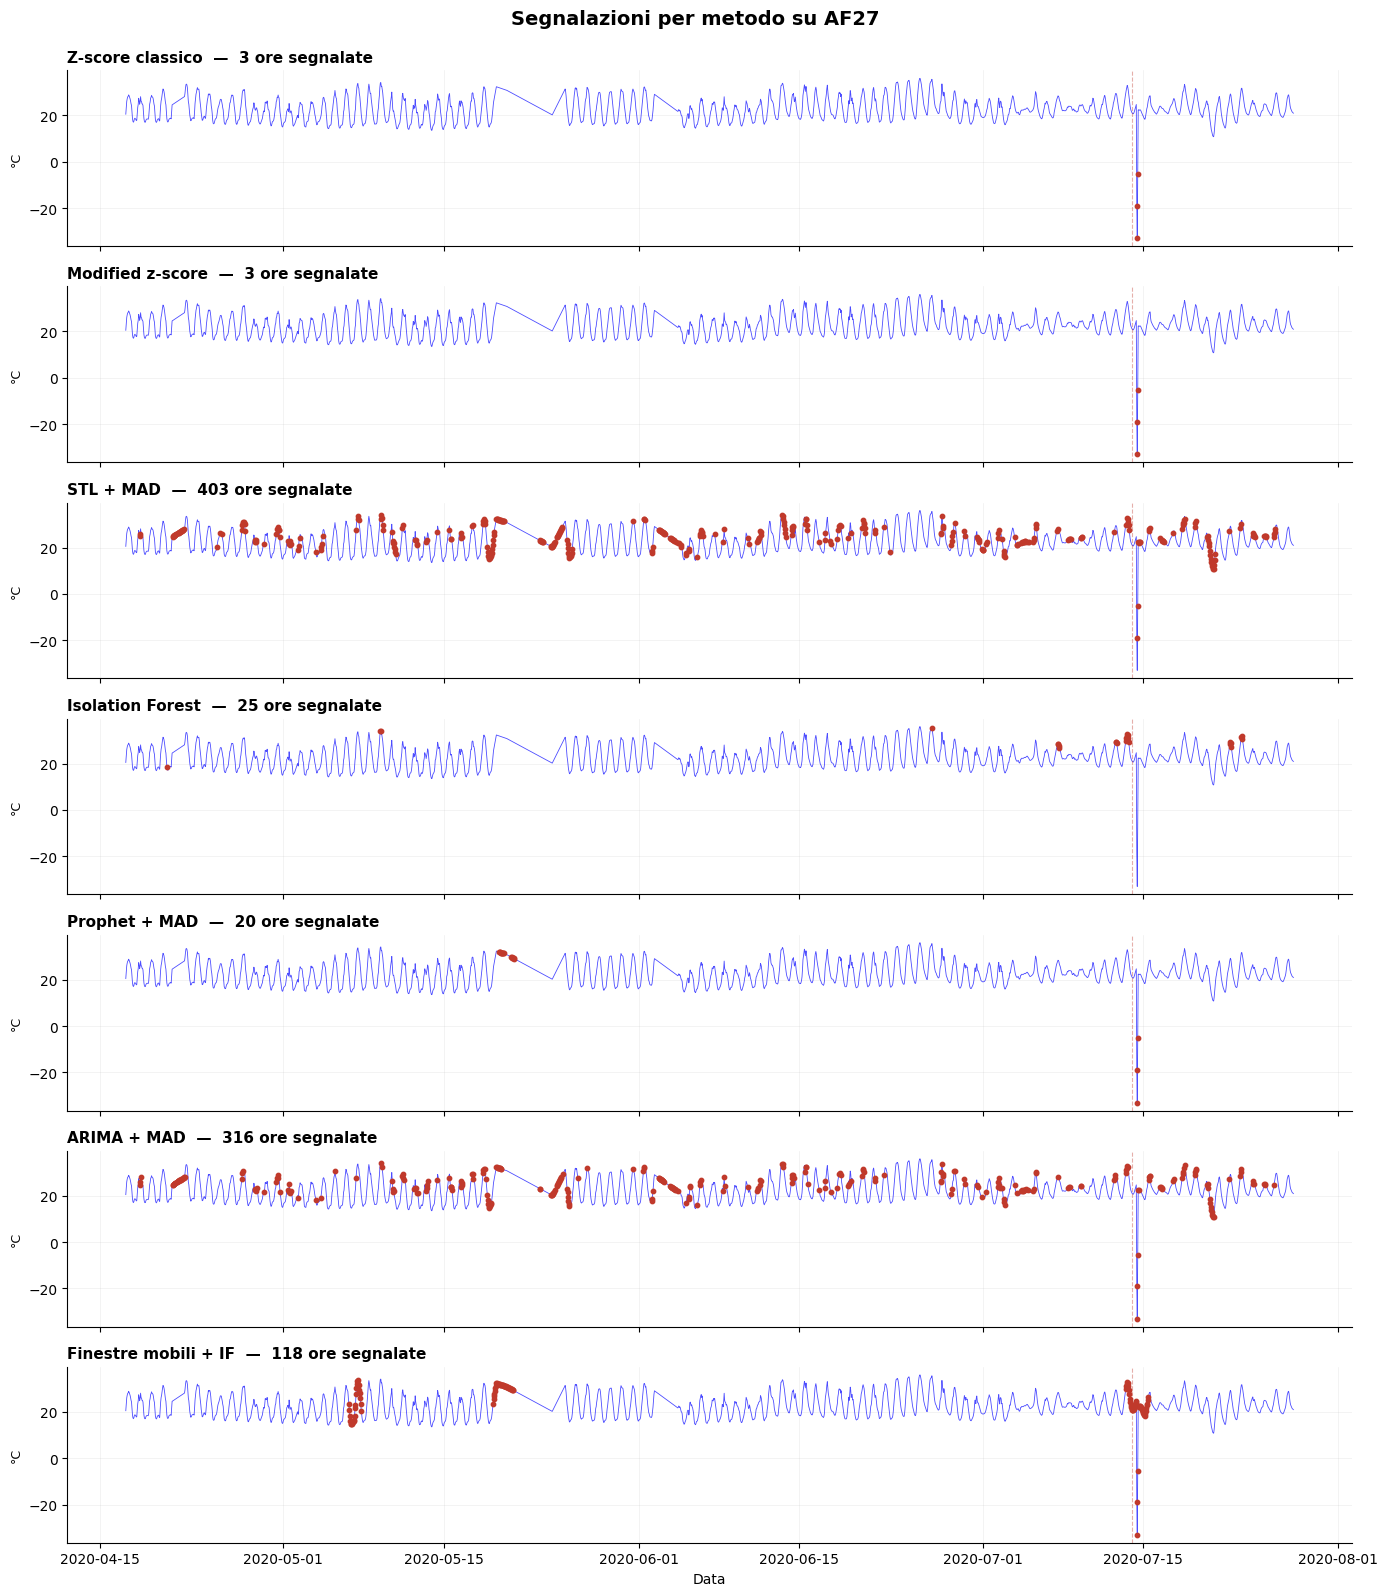

In [116]:
metodi = ['Z-score classico', 'Modified z-score', 'STL + MAD',
          'Isolation Forest', 'Prophet + MAD', 'ARIMA + MAD',
          'Finestre mobili + IF']

fig, axes = plt.subplots(len(metodi), 1, figsize=(14, 16), sharex=True)

for ax, metodo in zip(axes, metodi):
    ax.plot(orario.index, orario['temp_AF27'],
            color='blue', linewidth=0.6, alpha=0.7)
    seg = orario.loc[predizioni[metodo] == 1, 'temp_AF27']
    ax.scatter(seg.index, seg.values,
               color='#c0392b', s=10, zorder=5)
    ax.axvline(pd.Timestamp('2020-07-14'),
               color='#c0392b', linestyle='--', linewidth=0.8, alpha=0.4)

    n_seg = predizioni[metodo].sum()
    ax.set_title(f'{metodo}  —  {n_seg} ore segnalate',
                 loc='left', fontsize=11, fontweight='bold')
    ax.set_ylabel('°C', fontsize=9)
    ax.grid(alpha=0.2, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Data')
fig.suptitle('Segnalazioni per metodo su AF27',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

**Cosa emerge dal confronto visivo:**

- **Baseline (Z-score e Modified z-score)**: silenzio completo su tutto il
  periodo tranne il crollo del 14 luglio. Massima specificità sull'evento
  puntuale estremo, cecità totale su tutto il resto.
- **STL + MAD e ARIMA + MAD**: nuvola densa di segnalazioni distribuita
  lungo tutto il periodo. Alta sensibilità ai piccoli scostamenti dal
  comportamento atteso, con il rischio di sommergere l'operatore di
  allarmi. Notevole che STL segnali molti punti attorno
  al crollo ma non l'ora più estrema (12:00): l'auto-mascheramento
  discusso in 6A è visibile anche a occhio.
- **Isolation Forest**: 25 segnalazioni concentrate quasi tutte sui
  pomeriggi torridi di luglio (parte destra del grafico, valori alti),
  quasi nessuna in prossimità del crollo. Il metodo vede i giorni "estremi
  su tutti i sensori insieme", non i guasti localizzati a un singolo
  componente.
- **Prophet + MAD**: 20 segnalazioni ben distribuite, con visibile
  concentrazione sul 14 luglio. Buon equilibrio tra sensibilità e
  parsimonia, un allarme ogni ~5 giorni, gestibile in un contesto
  operativo reale.

Nessun singolo metodo è "il migliore" in senso
assoluto.

## Quadro ora per ora del 14 luglio
Il grafico seguente restringe l'analisi a una finestra di sei ore attorno al
guasto (10:00–15:00 del 14 luglio 2020) e mostra, per ciascuna delle tre ore
critiche, quali metodi hanno segnalato l'anomalia.

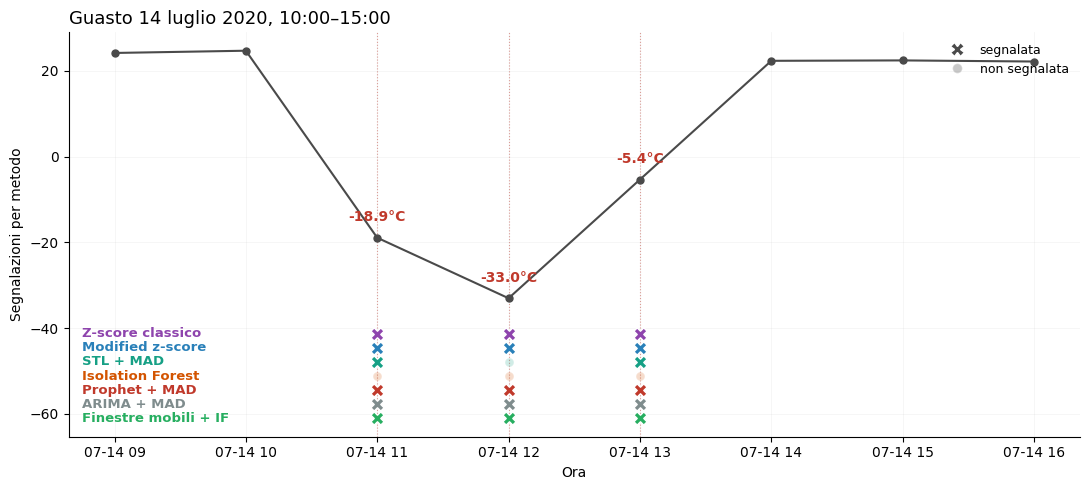

In [117]:
# Finestra di zoom
inizio_zoom = pd.Timestamp('2020-07-14 09:00')
fine_zoom = pd.Timestamp('2020-07-14 16:00')

fig, ax = plt.subplots(figsize=(11, 5))

# Serie di AF27 nella finestra
serie_zoom = orario.loc[inizio_zoom:fine_zoom, 'temp_AF27']
ax.plot(serie_zoom.index, serie_zoom.values,
        color='#4a4a4a', linewidth=1.5, marker='o', markersize=5,
        label='Temperatura AF27', zorder=3)

# Ore critiche del 14 luglio (11:00, 12:00, 13:00)
ore_critiche = [pd.Timestamp('2020-07-14 11:00'),
                pd.Timestamp('2020-07-14 12:00'),
                pd.Timestamp('2020-07-14 13:00')]

# Marker colorati per ciascun metodo, disposti su livelli verticali distinti
metodi_ordine = ['Z-score classico', 'Modified z-score', 'STL + MAD',
                 'Isolation Forest', 'Prophet + MAD', 'ARIMA + MAD',
                 'Finestre mobili + IF']
colori = ['#8e44ad', '#2980b9', '#16a085',
          '#d35400', '#c0392b', '#7f8c8d', '#27ae60']

#  marker sotto il grafico principale, uno per riga
y_min = serie_zoom.min() - 5
y_range = 23
step = y_range / len(metodi_ordine)

for i, (metodo, colore) in enumerate(zip(metodi_ordine, colori)):
    y_livello = y_min - (i + 1) * step
    for t in ore_critiche:
        marker = 'X' if predizioni.loc[t, metodo] == 1 else 'o'
        size = 90 if predizioni.loc[t, metodo] == 1 else 40
        alpha = 1.0 if predizioni.loc[t, metodo] == 1 else 0.2
        ax.scatter(t, y_livello, marker=marker, s=size,
                   color=colore, alpha=alpha, edgecolor='white', linewidth=1, zorder=4)
    ax.text(inizio_zoom - pd.Timedelta(minutes=15), y_livello, metodo,
            fontsize=9.5, ha='left', va='center', color=colore, fontweight='bold')

for t in ore_critiche:
    ax.axvline(t, color='#c0392b', linestyle=':', linewidth=0.8, alpha=0.5, zorder=1)

for t in ore_critiche:
    temp = orario.loc[t, 'temp_AF27']
    ax.annotate(f'{temp:.1f}°C', xy=(t, temp), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=10,
                fontweight='bold', color='#c0392b')

ax.set_title('Guasto 14 luglio 2020, 10:00–15:00',
             loc='left', fontsize=13)
ax.set_ylabel('Segnalazioni per metodo')
ax.set_xlabel('Ora')
ax.grid(alpha=0.15, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.lines import Line2D
custom_leg = [
    Line2D([0], [0], marker='X', color='w', markerfacecolor='#4a4a4a',
           markersize=10, label='segnalata'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4a4a4a',
           markersize=7, alpha=0.3, label='non segnalata')
]
ax.legend(handles=custom_leg, loc='upper right', frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

Mostra, per ciascuno dei sette metodi, quali delle tre ore
critiche del guasto (11:00, 12:00, 13:00) sono state segnalate come anomalia.
Il colpo d'occhio rende immediati i pattern discussi finora: la cecità completa
di Isolation Forest, l'auto-mascheramento di STL sull'ora peggiore, il sanity
check pieno degli altri cinque metodi.

## Risultati

Il confronto sistematico dei sette metodi mette in evidenza tre risultati:

**1. Il sanity check separa i metodi in tre gruppi.** Cinque metodi
(Z-score, modified z-score, Prophet, ARIMA, Finestre mobili + IF)
riconoscono entrambe le ore certificate del guasto. STL le riconosce solo
parzialmente per auto-mascheramento. Isolation Forest non le riconosce per
cecità dimensionale (guasto localizzato su 2 colonne su 10 rispetto a
pattern distribuiti su tutte le 10) ma è un limite che la sua stessa variante
a finestre mobili non condivide, applicata com'è a una rappresentazione
diversa dello stesso segnale.

**2. I tassi di allarme differiscono di ordini di grandezza.** Dalle 3
ore delle baseline alle 403 di STL c'è un fattore 100. Tuttavia il numero di
segnalazioni da solo non basta a giudicare la qualità del metodo: Prophet, con solo 20 ore segnalate (un allarme ogni circa 5 giorni), passa il
sanity check pieno. In un contesto operativo, sarebbe probabilmente il candidato più utilizzabile e gestibile.

**3. Il consenso tra metodi indipendenti isola il guasto e ne recupera
un dettaglio che il ground truth non poteva certificare.** Solo tre ore
in tutto il periodo di analisi raggiungono la concordanza di almeno
cinque metodi su sette, e sono tutte del 14 luglio 2020. Le due ore che
raggiungono il consenso massimo (6 metodi su 7) sono le 11:00 e le
**13:00**, quest'ultima esclusa dal ground truth conservativo perché
il dato grezzo era mancante. Sei metodi con logiche diverse hanno
concordato che quell'ora fosse anomala, e coerentemente col guasto in
corso probabilmente lo era: l'analisi comparativa ha recuperato
un'informazione che le etichette non contenevano.

Questi risultati, presi insieme, motivano la scelta di un confronto multi-dimensionale (sanity check + tassi di allarme +
consenso) che restituisce una lettura informativa e coerente con la
natura non supervisionata del task.

# 8. Conclusioni

L'obiettivo di questo lavoro non era ottimizzare un singolo rilevatore contro etichette complete, che nel task non esistono per costruzione, ma confrontare sistematicamente approcci di natura diversa e capire come la rappresentazione dei dati influenzi ciò che ciascun metodo riesce a vedere.

Il percorso metodologico è partito da due baseline statistiche globali
(z-score classico e modified z-score/MAD), per poi applicare la stessa
soglia statistica a rappresentazioni via via più informative dei dati:
i residui di una decomposizione STL e di un modello Prophet, i residui di
un ARIMA sui residui STL, lo stato multivariato istantaneo della serra
tramite Isolation Forest, e infine finestre mobili di 24 ore riassunte in
quattro statistiche aggregate, anch'esse passate a Isolation Forest. Il
guasto documentato di AF27 del 14 luglio 2020 è stato usato come sanity
check, non come metrica di ottimizzazione, e il consenso tra i sette
metodi indipendenti (majority voting) come indicatore di affidabilità
delle segnalazioni in assenza di etichette complete.

I risultati principali confermano la tesi centrale del lavoro: **la
rappresentazione dei dati conta più della scelta dell'algoritmo**.
Isolation Forest applicato allo stato grezzo a 10 dimensioni non vede il
guasto (cecità dimensionale), ma lo stesso algoritmo applicato a finestre
aggregate lo rileva pienamente; STL soffre di auto-mascheramento su
un'ora, corretto in parte applicando ARIMA sui suoi stessi residui. Il
consenso tra metodi, calcolato senza mai usare le etichette, isola da
solo le tre ore del guasto e recupera le 13:00, un'ora che il ground
truth conservativo non poteva certificare per un dato grezzo mancante,
ma su cui sei metodi indipendenti concordano.

Il progetto conferma quindi il valore di un'analisi comparativa
multi-dimensionale (sanity check, tassi di allarme, consenso) rispetto a
una singola metrica quantitativa, in un task dove il ground truth
disponibile è per natura parziale.

## Limiti del lavoro

Il progetto presenta alcuni limiti strutturali che è importante dichiarare
per una corretta interpretazione dei risultati.

**Limitatezza del ground truth.** L'unico evento anomalo certificato dai
dati grezzi è il guasto hardware di AF27 del 14 luglio, che copre due ore.
Le anomalie contestuali (deviazioni locali dal ciclo giornaliero, visibili
nella decomposizione STL della Sezione 4) restano non etichettate. Per
questa ragione la valutazione principale è stata comparativa e non quantitativa: precision/recall calcolati contro un ground truth così
incompleto ne misurerebbero l'incompletezza, non la qualità dei metodi.

**Interpolazione dei valori mancanti.** Il ricampionamento orario ha
generato ore vuote laddove i sensori non hanno trasmesso, interpolate
tramite `method='time'`. Sui gap lunghi (in particolare AF36) l'interpolazione produce tratti artificialmente lineari in cui nessuna anomalia è più rilevabile.

**Numero dei sensori.** L'analisi si concentra su 5 dei 27 sensori
del dataset originale, scelti perché unici con copertura del periodo del
guasto. Le conclusioni sono quindi valide per questo sottoinsieme.

**Iperparametri dichiarati.** Le soglie utilizzate (3.5 per il modified
z-score, contamination 0.01 per Isolation Forest, ordine (2,0,2) per
ARIMA, fourier_order 5 per Prophet) sono giustificate ma restano
iperparametri sensibili al dominio. L'analisi di sensibilità della soglia
condotta in Sezione 5 mostra che, per i metodi baseline, il risultato è
robusto tra 3.5 e 3.0 e degrada per valori inferiori. Analisi analoghe
per gli altri metodi rappresentano una possibile estensione.

## Sviluppi futuri

Alla luce dei limiti dichiarati potrebbero esserci alcune direzioni di estensione.

**Annotazione manuale di anomalie contestuali.** Come discusso tra i
limiti, l'assenza di ground truth per le anomalie contestuali impedisce
la loro valutazione quantitativa. Un'estensione naturale sarebbe
l'annotazione retrospettiva, da parte di un esperto agronomo, di ore
sospette individuate dai residui STL o Prophet, per costruire un
ground truth arricchito e misurare la performance dei metodi
contestuali oltre il singolo evento del guasto.

**Modelli sequenziali profondi.** Per catturare dipendenze temporali a
lungo raggio, un LSTM Autoencoder addestrato in modalità non
supervisionata sul comportamento normale rappresenta un'estensione
metodologicamente naturale: l'anomalia verrebbe identificata come una
ricostruzione con errore superiore a una soglia. Il costo è
principalmente computazionale e in termini di dati necessari per un
addestramento stabile.

**Generazione di dati sintetici per validazione.** Tecniche generative permetterebbero di produrre serie temporali sintetiche con anomalie note per validare i metodi in condizioni controllate. Va tuttavia notato che le tecniche generative più diffuse (come CTGAN) sono pensate per dati tabellari indipendenti, il loro adattamento a serie temporali richiede attenzione metodologica ed è argomento di ricerca attiva.

**La relazione fisica inversa tra temperatura e umidità**, documentata dagli stessi autori dell'articolo e confermata dal crollo simultaneo dei due canali durante il guasto, non è mai stata testata come segnale indipendente: molti dei  metodi confrontati operano esclusivamente sul canale di temperatura (Isotion Forest multivariato incorpora anche l'umidità).
Un'analisi naturale ma non sviluppata in questo lavoro sarebbe una regressione dell'umidità in funzione della temperatura, con MAD sui residui, per isolare le ore in cui questa relazione attesa si rompe, un segnale strutturalmente
indipendente dal canale su cui si basa la maggioranza dei metodi qui
confrontati.

---
## Fonti

- **Singh, D. K., Sobti, R., Jain, A., Malik, P. K., & Le, D. N.** (2022). *LoRa
  based intelligent soil and weather condition monitoring with internet of
  things for precision agriculture in smart cities*. Sensors, 22(17), 6389.
  https://www.mdpi.com/1424-8220/22/4/1326

- **Dataset** disponibile su Zenodo:
  https://doi.org/10.5281/zenodo.5793685


- **Sebastian Raschka, Yuxi (Hayden) Liu, Vahid Mirjalili**,
  *Machine Learning with PyTorch and Scikit-Learn*, Cap. 7
  *Combining Different Models for Ensemble Learning*.